In [16]:
# Import Libraries
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import lasio

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2

ImportError: cannot import name 'r2' from 'sklearn.metrics' (c:\Users\sadar\anaconda3\envs\ml4pegs\Lib\site-packages\sklearn\metrics\__init__.py)

In [2]:
# Input and output paths
ROOT = Path().resolve().parent
RAW  = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed' 
PROCESSED.mkdir(parents=True, exist_ok=True)

## Loading and Visualizing LAS

In [3]:
# Check the wells and logs available in the LAS files
well_names = ["BLT-01", "JUT-01", "EVD-01", "PKP-01"]
dfs_las = {}

for well in well_names:
    las = lasio.read(RAW / f"{well}.las")
    df_las = las.df()
    df_las.index.name = "MD"
    df_las = df_las.reset_index()

    dfs_las[well] = df_las

    print(f"\nWell Name: {well}")
    print("LAS DataFrame shape:", df_las.shape)
    print("Columns:", list(df_las.columns))
    df_las.head(8)


Well Name: BLT-01
LAS DataFrame shape: (27875, 20)
Columns: ['MD', 'BITSIZE', 'CALI', 'CASING_FLAG-(S)GR_NPHI_DTC', 'DRHO', 'DTC', 'DTS', 'DTST', 'GR', 'GRKT', 'GRTO', 'NPHI', 'PE', 'POTA', 'RD', 'RHOB', 'RM', 'RS', 'THOR', 'URAN']

Well Name: JUT-01
LAS DataFrame shape: (22427, 5)
Columns: ['MD', 'DEPT:2', 'GR', 'DT', 'RHOB']

Well Name: EVD-01
LAS DataFrame shape: (21569, 5)
Columns: ['MD', 'GR', 'DT', 'RHOB', 'DRHO']

Well Name: PKP-01
LAS DataFrame shape: (27508, 6)
Columns: ['MD', 'GR', 'DT', 'RHOB', 'DRHO', 'NPHI']


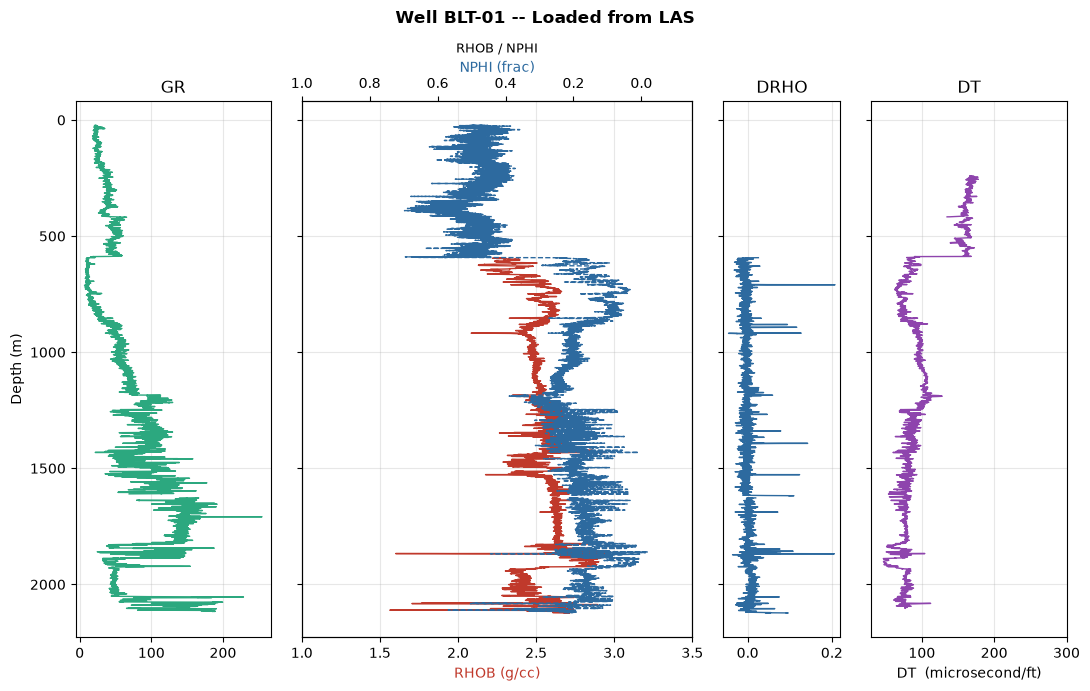

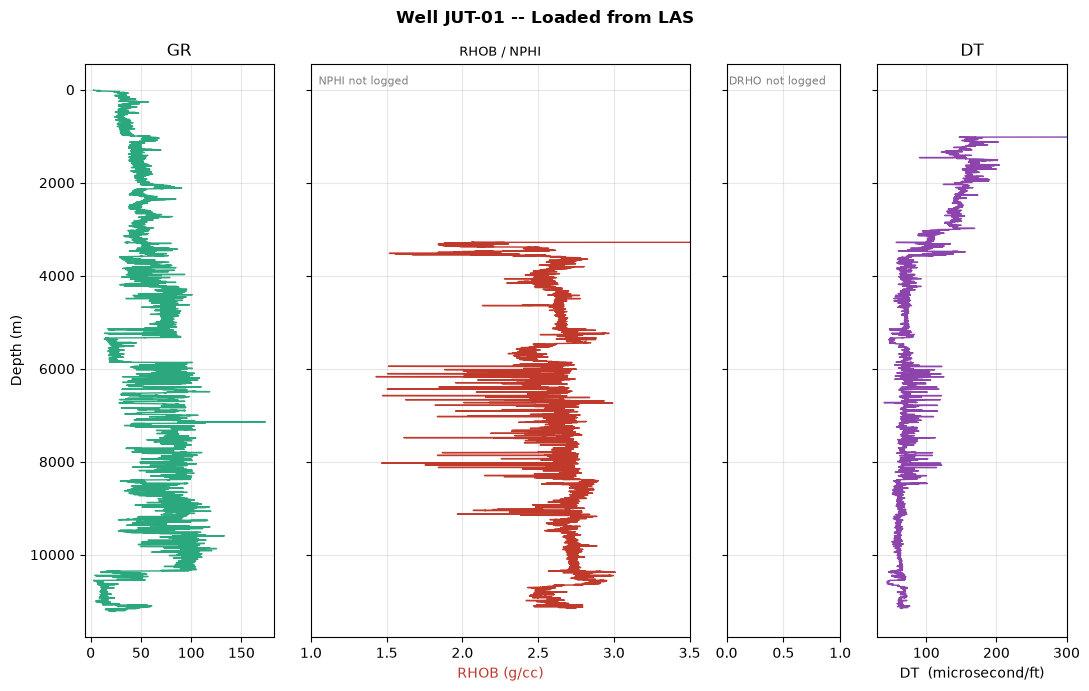

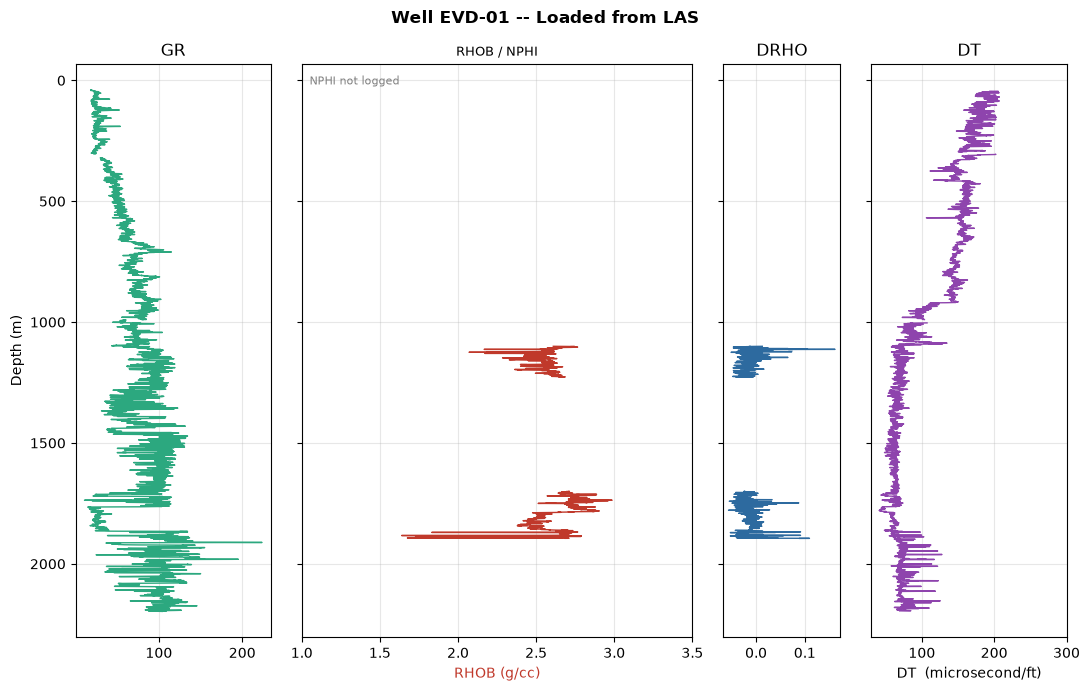

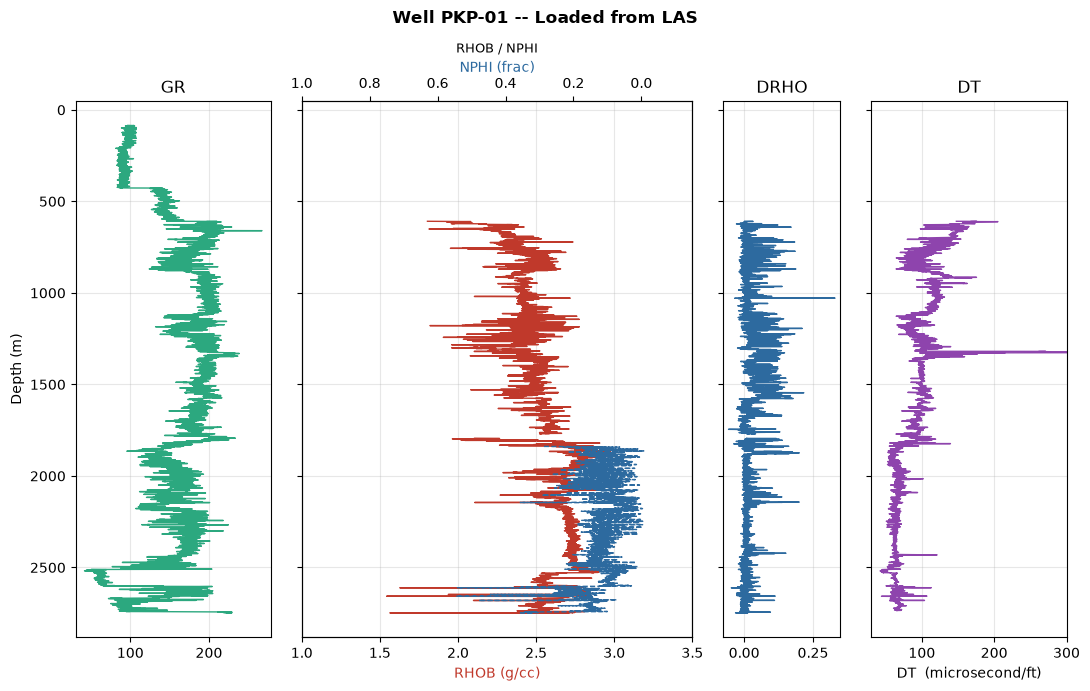

In [4]:
well_figures = {}

# GR, RHOB, NPHI, DRHO, DT/DTC logs plotted
for well in well_names:
    df_las = dfs_las[well]

    df_las_clean = df_las.sort_values("MD")

    fig, axes = plt.subplots(1, 4, figsize=(11, 7), sharey=True, gridspec_kw={"width_ratios": [1, 2, 0.6, 1]})
    fig.suptitle(f"Well {well} -- Loaded from LAS", fontsize=12, fontweight="bold")

    axes[0].plot(df_las_clean["GR"], df_las_clean["MD"], color="#2ca87f", linewidth=1)
    axes[0].set_label("GR (API)") 
    axes[0].set_title("GR") 
    axes[0].invert_yaxis() 
    axes[0].set_ylabel("Depth (m)") 

    ax2a = axes[1]
    ax2a.plot(df_las_clean["RHOB"], df_las_clean["MD"], color="#c0392b", linewidth=1, label="RHOB")
    ax2a.set_xlabel("RHOB (g/cc)", color="#c0392b")

    if "NPHI" in df_las_clean.columns:
        ax2b = ax2a.twiny()
        ax2b.plot(df_las_clean["NPHI"], df_las_clean["MD"], color="#2d6a9f", linewidth=1, linestyle="--", label="NPHI")
        ax2b.set_xlabel("NPHI (frac)", color="#2d6a9f")
    else:
        ax2a.text(0.02, 0.98, "NPHI not logged", transform=ax2a.transAxes, va="top", fontsize=8, color="gray")
    axes[1].set_title("RHOB / NPHI", fontsize=9) 
    ax2a.set_xlim(1.0, 3.5)
    ax2b.set_xlim(1.0, -0.15)

    if "DRHO" in df_las_clean.columns:
        axes[2].plot(df_las_clean["DRHO"], df_las_clean["MD"], color="#2d6a9f", linewidth=1)
        axes[2].set_label("DRHO  (g/cc)")
        axes[2].set_title("DRHO")
    else:
        axes[2].text(0.02, 0.98, "DRHO not logged", transform=axes[2].transAxes, va="top", fontsize=8, color="gray")

    dt_col = "DT" if "DT" in df_las_clean.columns else ("DTC" if "DTC" in df_las_clean.columns else None)

    axes[3].plot(df_las_clean[dt_col], df_las_clean["MD"], color="#8e44ad", linewidth=1)
    axes[3].set_xlabel("DT  (microsecond/ft)")
    axes[3].set_title("DT")
    axes[3].set_xlim(30, 300)

    for ax in axes: 
        ax.grid(True, alpha=0.3)

    well_figures[well] = fig 
    plt.tight_layout() 
    plt.show()

## Loading CSV

In [5]:
# Load raw target lithologies data
raw_data = pd.read_csv(RAW / "target_lithologies.csv")
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3455 entries, 0 to 3454
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                3455 non-null   str    
 1   easting                3455 non-null   float64
 2   northing               3455 non-null   float64
 3   depth_tvd_m            0 non-null      float64
 4   porosity_pct           2419 non-null   float64
 5   gamma_ray_api          3455 non-null   float64
 6   bulk_density_gcc       3199 non-null   float64
 7   formation_top_tvd      3455 non-null   float64
 8   formation_base_tvd     3455 non-null   float64
 9   formation_thickness_m  3455 non-null   float64
 10  distance_to_usp_km     3455 non-null   float64
 11  flag                   3455 non-null   str    
 12  flag_reason            3455 non-null   str    
dtypes: float64(10), str(3)
memory usage: 351.0 KB


## Checking 'well_id'

In [6]:
df = raw_data.copy() 
df['well_id'].value_counts()

well_id
BLT-01    1689
EVD-01     780
PKP-01     730
JUT-01     256
Name: count, dtype: int64

## Checking empty rows

In [7]:
# 'depth_tvd_m'
missing_rows = df[df['depth_tvd_m'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing depth_tvd_m counts per well:")
    print(missing_rows)

# 'porosity_pct'
missing_rows = df[df['porosity_pct'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing porosity_pct counts per well:")
    print(missing_rows)

# 'bulk_density_gcc'
missing_rows = df[df['bulk_density_gcc'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing bulk_density_gcc counts per well:")
    print(missing_rows)


Missing depth_tvd_m counts per well:
well_id
BLT-01    1689
EVD-01     780
JUT-01     256
PKP-01     730
dtype: int64

Missing porosity_pct counts per well:
well_id
EVD-01    780
JUT-01    256
dtype: int64

Missing bulk_density_gcc counts per well:
well_id
JUT-01    256
dtype: int64


### Filling in 'depth_tvd_m'

In [8]:
def fill_depth(well_id, las_file, sheet_name, top_depth, bottom_depth, md_col):
    # Well path data
    wellpath = pd.read_excel(RAW / 'Well Path Data.xlsx', sheet_name=sheet_name)
    wellpath_df = wellpath[['Depth (m)', 'TVD (m)']]

    # Source data from LAS file
    las = dfs_las[well_id]

    # Subset formation interval
    subset = las[(las[md_col] >= top_depth) & (las[md_col] <= bottom_depth)]

    # Interpolate TVD
    subset['depth_tvd_m'] = np.interp(subset[md_col], wellpath_df['Depth (m)'], wellpath_df['TVD (m)'])

    # Merge with target lithologies
    target_subset = df[df['well_id'] == well_id]
    df.loc[target_subset.index, 'depth_tvd_m'] = subset['depth_tvd_m'].values[:len(target_subset)]

In [9]:
# Apply to all wells
fill_depth('BLT-01', 'BLT-01log.csv', 'BLT-01', 1924, 2052.7, 'MD')
fill_depth('EVD-01', 'EVD-01log.csv', 'EVD-01', 1788, 1866, 'MD')
fill_depth('JUT-01', 'JUT-01log.csv', 'JUT-01', 1659.5, 1787, 'DEPT:2')
fill_depth('PKP-01', 'PKP-01log.csv', 'PKP-01', 2530.5, 2603.5, 'MD')

In [10]:
well_list = df['well_id'].unique().tolist()
print(f"\nThis  is a list of all the wells in target_lithologies.csv: {well_list}")
log_cols = ["porosity_pct", "gamma_ray_api", "bulk_density_gcc"]
print(f"\nThese are the log columns in target_lithologies.csv: {log_cols}")


This  is a list of all the wells in target_lithologies.csv: ['JUT-01', 'EVD-01', 'PKP-01', 'BLT-01']

These are the log columns in target_lithologies.csv: ['porosity_pct', 'gamma_ray_api', 'bulk_density_gcc']


## Log and Target CSV Overlay

C:\Users\sadar\AppData\Local\Temp\ipykernel_2512\2236410687.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\sadar\AppData\Local\Temp\ipykernel_2512\2236410687.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


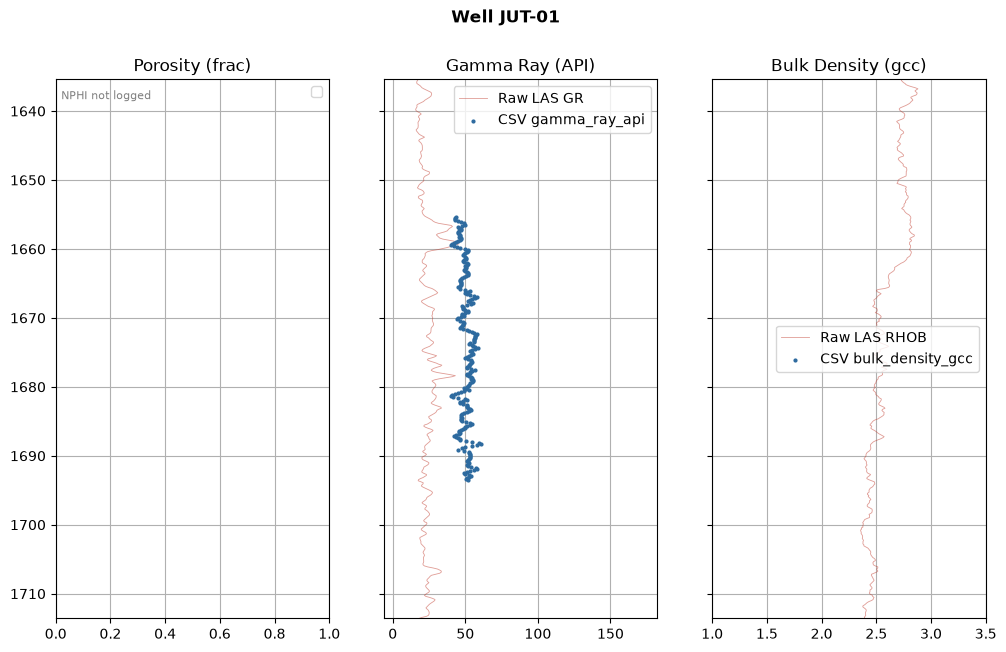

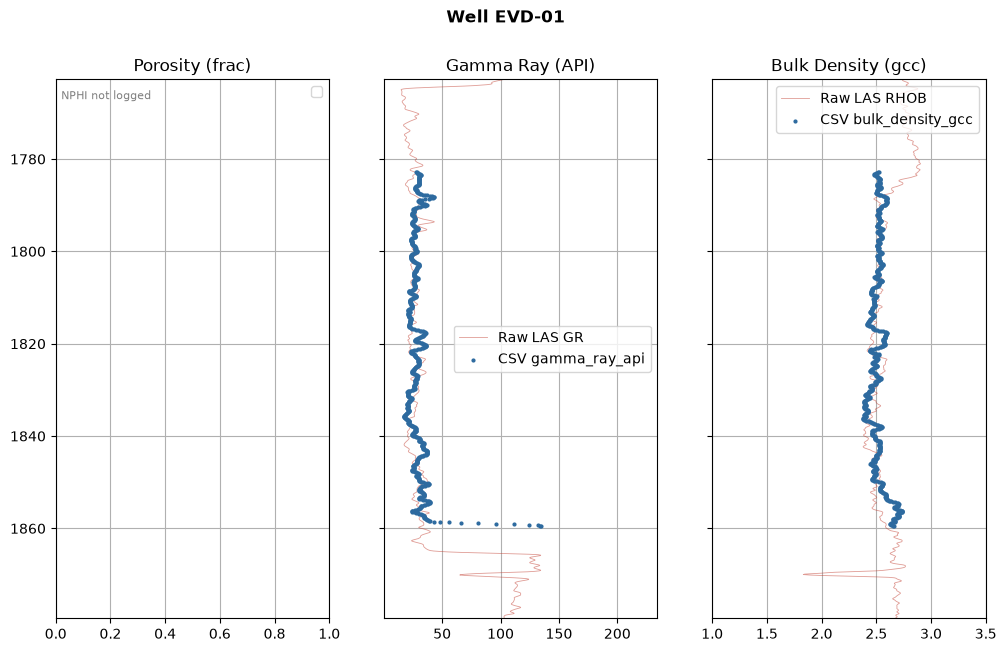

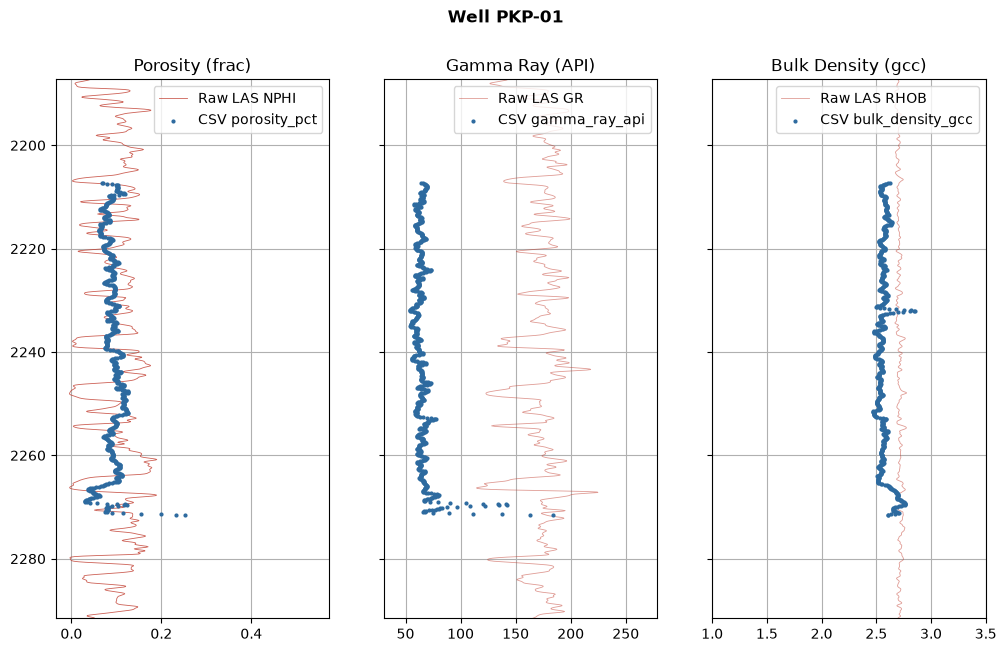

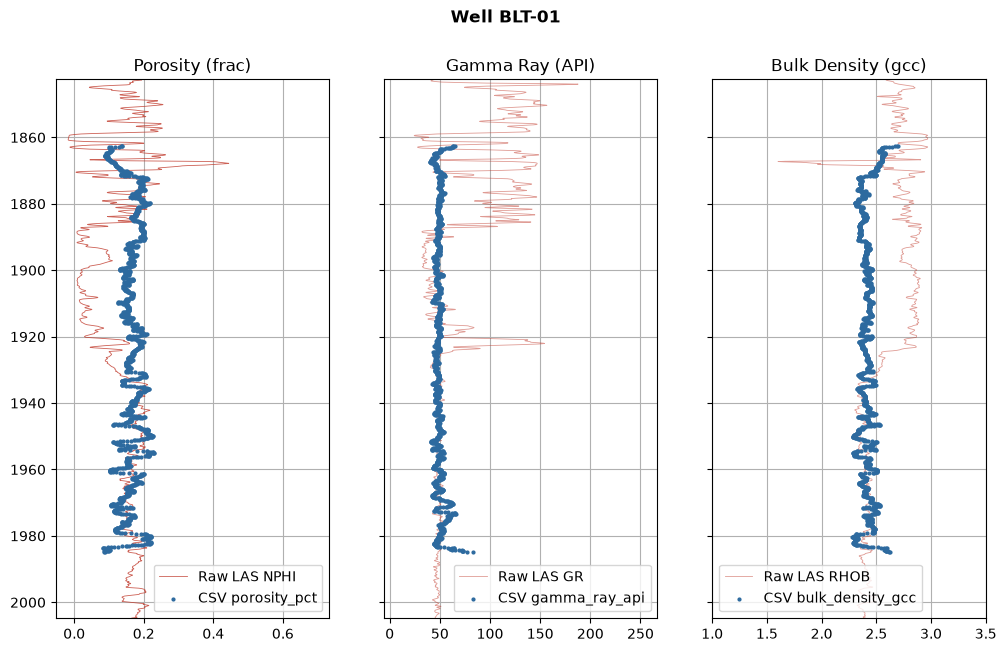

In [11]:
for well in well_list:
    well_log = dfs_las[well]
    csv_rows =df[df["well_id"] == well].reset_index()

    depth_col = "DEPT:2" if "DEPT:2" in well_log.columns else "MD" # JUT-01's MD column is in feet

    has_nphi = "NPHI" in well_log.columns

    fig, axes = plt.subplots(1, 3, figsize=(12, 7), sharey = True)
    fig.suptitle(f"Well {well}", fontsize=12, fontweight="bold")
    if has_nphi:
        axes[0].plot(well_log["NPHI"], well_log[depth_col], color="#c0392b", linewidth=0.6, alpha=0.8, label="Raw LAS NPHI")
        axes[0].scatter(csv_rows["porosity_pct"]/100, csv_rows["depth_tvd_m"], color="#2d6a9f", s=4, zorder=5, label="CSV porosity_pct")
    else:
        axes[0].text(0.02, 0.98, "NPHI not logged", transform=axes[0].transAxes, va="top", fontsize=8, color="gray")
    axes[0].set_title("Porosity (frac)")

    axes[1].plot(well_log["GR"], well_log[depth_col], color="#c0392b", linewidth=0.6, alpha=0.5, label="Raw LAS GR")
    axes[1].scatter(csv_rows["gamma_ray_api"], csv_rows["depth_tvd_m"], color="#2d6a9f", s=4, zorder=5, label="CSV gamma_ray_api")
    axes[1].set_title("Gamma Ray (API)")

    axes[2].plot(well_log["RHOB"], well_log[depth_col], color="#c0392b", linewidth=0.6, alpha=0.5, label="Raw LAS RHOB")
    axes[2].scatter(csv_rows["bulk_density_gcc"], csv_rows["depth_tvd_m"], color="#2d6a9f", s=4, zorder=5, label="CSV bulk_density_gcc")
    axes[2].set_xlim(1.0, 3.5)
    axes[2].set_title("Bulk Density (gcc)")

    for ax in axes:
        ax.set_ylim(csv_rows["depth_tvd_m"].max() + 20, csv_rows["depth_tvd_m"].min() - 20)
        ax.grid()
        ax.legend()

## Well 'JUT-01'

In [12]:
# Wrong depth intervals in CSV. Depth(ft) was used instead of Depth(m)
las_jut = dfs_las["JUT-01"].reset_index()

subset = las_jut[(las_jut['DEPT:2'] >= 1659.5) & (las_jut['DEPT:2'] <= 1787)].copy()
subset = subset.dropna(subset=['GR', 'RHOB'])

new_rows = subset[['DEPT:2', 'GR', 'RHOB']].rename(columns={
    'DEPT:2': 'depth_tvd_m',
    'GR': 'gamma_ray_api',
    'RHOB': 'bulk_density_gcc'
}).copy()

new_rows['well_id'] = 'JUT-01'
new_rows['easting'] = 134098
new_rows['northing'] = 451726
new_rows['formation_top_tvd'] = 1659.5
new_rows['formation_base_tvd'] = 1787
new_rows['formation_thickness_m'] = 127.5
new_rows['distance_to_usp_km'] = 7.748433713
new_rows['flag'] = 'check'
new_rows['flag_reason'] = 'AH depth -- deviated well needs TVD conversion before use'

df = df[df['well_id'] != 'JUT-01']
df = pd.concat([df, new_rows], ignore_index=True)

## Checking empty rows

In [13]:
# 'depth_tvd_m'
missing_rows = df[df['depth_tvd_m'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing depth_tvd_m rows') 
else:
    print("\nMissing depth_tvd_m counts per well:")
    print(missing_rows)

# 'porosity_pct'
missing_rows = df[df['porosity_pct'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing porosity_pct rows') 
else:
    print("\nMissing porosity_pct counts per well:")
    print(missing_rows)

# 'bulk_density_gcc'
missing_rows = df[df['bulk_density_gcc'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing bulk_density_gcc rows') 
else:
    print("\nMissing bulk_density_gcc counts per well:")
    print(missing_rows)


No missing depth_tvd_m rows

Missing porosity_pct counts per well:
well_id
EVD-01    780
JUT-01    836
dtype: int64

No missing bulk_density_gcc rows


## Classic 'Bulk Density' vs 'Porosity' Relationship

Well PKP-01 correlation coefficient: -0.472
Well BLT-01 correlation coefficient: -0.949


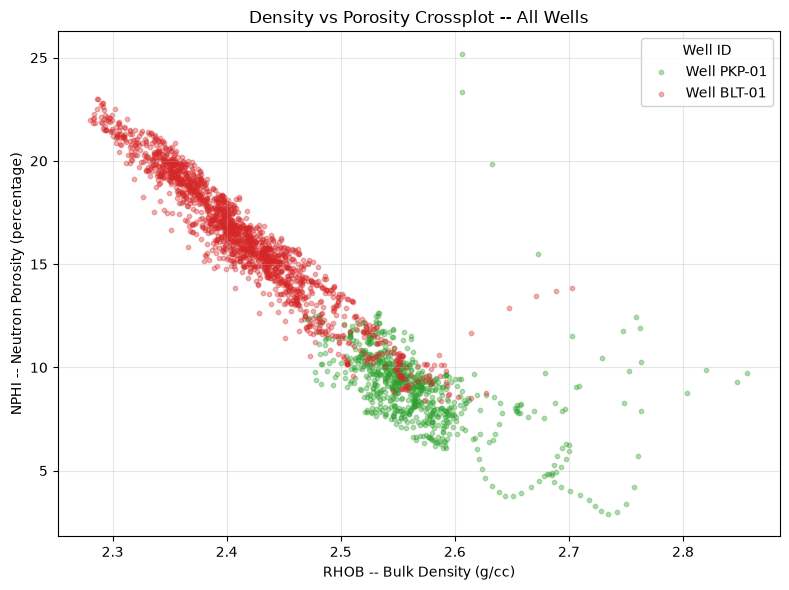

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = cm.tab10.colors

for i, well_id in enumerate(well_list):
    well_df = df[df["well_id"] == well_id]
    if well_df["bulk_density_gcc"].notna().any() and well_df["porosity_pct"].notna().any():
        ax.scatter(
            well_df["bulk_density_gcc"],
            well_df["porosity_pct"],
            alpha=0.35,
            s=10,
            color=colors[i % len(colors)],
            label=f"Well {well_id}"
        )
        corr = well_df["bulk_density_gcc"].corr(well_df["porosity_pct"])
        print(f"Well {well_id} correlation coefficient: {round(corr, 3)}")

ax.set_xlabel("RHOB -- Bulk Density (g/cc)")
ax.set_ylabel("NPHI -- Neutron Porosity (percentage)")
ax.set_title("Density vs Porosity Crossplot -- All Wells")
ax.grid(True, alpha=0.3)
ax.legend(title="Well ID", loc="best", framealpha=0.9)
plt.tight_layout()
plt.show()

## Linear Regression

In [15]:
# 🎯 Your code here -- Build a model to predict SW_frac from RT_ohmm

# Step 1: Select feature and target
X = df[["bulk_density_gcc"]]
y = df["porosity_pct"] 

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Step 3: Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Make predictions on the test set
y_pred = model.predict(X_test) 

# Step 5: Evaluate -- print R2, RMSE, and the equation
r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=== Model Performance on Test Set ===")
print(f"  R-squared (R2) : {r2:.4f}")
print(f"  RMSE           : {rmse:.4f}  (SW units: frac)")
print(f"\n Equation: SW = {model.coef_[0]:.4f} * RT + {model.intercept_:.4f}")
if r2 > 0.7:
    print("\n  Assessment: Good fit -- the model explains most of the variation.")
elif r2 > 0.4:
    print("\n Assessment: Moderate fit -- there is real signal but also unexplained scatter.")
else: 
    print("\n Assessment: Weak fit -- a single feature is not enough to explain SW_frac variation.")

# Step 6: Plot Actual vs Predicted
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred, alpha=0.3, s=12, color="#2d6a9f")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], color="#c0392b", linewidth=1.5, linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual SW (frac)")
ax.set_ylabel("Predicted SW (frac)")
ax.set_title("Actual vs Predicted")
ax.legend(fontsize=8) 
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


NameError: name 'train_test_split' is not defined